##🧪 Week 10: 물리적 수치 기반 Face Anti-Spoofing 분석
- **연구 목표:** 딥러닝의 '블랙박스' 문제를 극복하기 위해, 진짜 얼굴과 위조 공격(Print, Replay) 간의 주파수 및 선명도 수치 차이를 증명하고 분석함.

###📌 주요 분석 전략 (Feedback 반영)
- FFT (Fast Fourier Transform): 인쇄 망점 및 모아레 현상으로 인한 고주파 에너지 분포 확인.
- Laplacian Variance: 재촬영 시 발생하는 경계면 뭉개짐(Blur) 수치 정량화.
- Smart Sampling: 200GB 대용량 데이터셋에서 분석에 핵심적인 60,000장(Live/Print/Replay)을 선별 추출하여 효율적 분석 수행.

### 📂 현재 진행 단계

- [ ] CelebA-Spoof 메타데이터(intra_test) 파싱 완료

- [ ] (현재) 공격 유형별 샘플 이미지(Live/Print/Replay)를 다운로드

- [ ] FFT 및 Laplacian 수치 분포 시각화 및 임계값(Threshold) 도출

##🛠️ 1단계: 분석용 샘플 경로 추출 [05.11]
 - 이 코드는 train_label.txt라는 거대한 지도에서 우리가 분석할 특정 좌표(이미지 경로)만 쏙쏙 뽑아내는 역할

### 왜 index 40인가?:
- CelebA-Spoof 데이터셋 정의서에 따르면, 41번째 열(Python index 40)이 공격 유형을 결정하는 핵심 라벨에 해당

- 분류 로직: target_samples라는 딕셔너리를 만들어 데이터를 카테고리별로 자동 분류

In [ ]:
# 파일의 첫 줄을 읽어서 데이터가 몇 개인지 확인하는 디버깅 코드입니다.
with open(LABEL_PATH, 'r') as f:
    first_line = f.readline().strip()
    parts = first_line.split()
    print(f"📄 첫 번째 줄 내용 샘플: {first_line[:100]}...") # 너무 길 수 있으니 앞부분만
    print(f"📊 한 줄에 들어있는 데이터 개수: {len(parts)}개")

# 만약 개수가 41개 미만이라면, 우리가 찾던 index 40이 여기에 없는 겁니다!

📄 첫 번째 줄 내용 샘플: Data/train/2623/live/000000.jpg 0...
📊 한 줄에 들어있는 데이터 개수: 2개


## 문제점!!
- 해당 파일에는 0,1로만 존재하는 이진 데이터만 존재하는 문제점
- 이를 통해서는 단순 분류기 이상으로 제작이 불가능하므로 더 상세한 데이터를 가진 label을 찾아야 한다

## 다른 데이터 라벨 찾기

In [ ]:
import os

# [설명] intra_test 폴더 안에 있는 83MB짜리 진짜 지도를 타겟팅합니다.
TARGET_JSON = 'CelebA_Spoof/metas/intra_test/train_label.json'

print(f"📡 상세 라벨이 담긴 JSON 파일을 불러옵니다...")

# Kaggle에서 JSON 파일 정밀 다운로드
!kaggle datasets download -d mabdullahsajid/celeba-spoofing -f {TARGET_JSON} --path .

# 압축 해제 및 파일명 정리
if os.path.exists('train_label.json.zip'):
    !unzip -o train_label.json.zip
    print("✅ 상세 지도(train_label.json) 확보 성공!")
else:
    print("❌ 파일을 가져오지 못했습니다. 경로를 다시 확인해주세요.")

📡 상세 라벨이 담긴 JSON 파일을 불러옵니다...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 5.85M/5.85M [00:00<00:00, 15.1MB/s]

Archive:  train_label.json.zip
  inflating: train_label.json        
✅ 상세 지도(train_label.json) 확보 성공!


다운로드한 데이터의 구성을 확인하기

In [ ]:
import json

if os.path.exists('train_label.json'):
    with open('train_label.json', 'r') as f:
        data = json.load(f)

    # [설명] JSON의 첫 번째 아이템을 가져와서 구조를 봅니다.
    first_key = list(data.keys())[0]
    attributes = data[first_key]

    print(f"📍 이미지 경로: {first_key}")
    print(f"📊 포함된 데이터 개수: {len(attributes)}개")

    # 41번째(index 40) 데이터가 우리가 찾는 공격 유형인지 확인
    if len(attributes) > 40:
        print(f"🎯 찾았다! 41번째 데이터(공격유형): {attributes[40]}")
    else:
        print("⚠️ 이 파일에도 상세 정보가 부족합니다. 다른 파일을 찾아야 할 수도 있습니다.")

📍 이미지 경로: Data/train/2623/live/000000.jpg
📊 포함된 데이터 개수: 44개
🎯 찾았다! 41번째 데이터(공격유형): 0


올바른 데이터셋을 찾았으니, 여기서 샘플 20장을 추출함

그 전에 타입에 대한 설정을 먼저 실행

In [47]:
import random
import json
from collections import Counter

# 타입별 정확한 매핑
TYPE_MAP = {
    'live':     [0],
    'print':    [1, 2, 6, 8],
    'replay':   [3, 5, 7],
    'toy':      [10],
}

# 카테고리별 5장씩 샘플링
target_samples = {}

for category, type_nums in TYPE_MAP.items():
    # 해당 타입 번호에 맞는 경로 전부 수집
    pool = [p for p, l in meta.items() if l[40] in type_nums]
    print(f"[{category}] 전체 pool: {len(pool)}장")

    # 5장 랜덤 샘플
    target_samples[category] = random.sample(pool, 5)

print("\n✅ target_samples 확정:")
for cat, paths in target_samples.items():
    print(f"[{cat}] {len(paths)}장 | 예시: {paths[0]}")

[live] 전체 pool: 162462장
[print] 전체 pool: 133138장
[replay] 전체 pool: 93015장
[toy] 전체 pool: 40616장

✅ target_samples 확정:
[live] 5장 | 예시: Data/train/6718/live/277903.jpg
[print] 5장 | 예시: Data/train/938/spoof/129054.jpg
[replay] 5장 | 예시: Data/train/4161/spoof/336923.jpg
[toy] 5장 | 예시: Data/train/9313/spoof/105647.jpg


In [55]:
import os
import glob
import shutil

print("📥 Kaggle에서 샘플 이미지 다운로드 시작\n")

for category, paths in target_samples.items():
    save_dir = f"./samples/{category}"
    os.makedirs(save_dir, exist_ok=True)

    for p in paths:
        kaggle_full_path = "CelebA_Spoof/" + p
        filename = p.split('/')[-1]

        print(f"🚀 {category} / {filename} 다운로드 중...")

        tmp_dir = f"./tmp_dl/{category}"
        os.makedirs(tmp_dir, exist_ok=True)

        !kaggle datasets download -d mabdullahsajid/celeba-spoofing \
            -f "{kaggle_full_path}" \
            -p "{tmp_dir}"

        zips = glob.glob(os.path.join(tmp_dir, "*.zip"))
        for zip_path in zips:
            !unzip -q -o "{zip_path}" -d "{tmp_dir}"
            os.remove(zip_path)

        found = glob.glob(os.path.join(tmp_dir, "**", filename), recursive=True)
        if found:
            shutil.copy(found[0], os.path.join(save_dir, filename))
            print(f"  ✅ 저장 완료: ./samples/{category}/{filename}")
        else:
            print(f"  ❌ 파일 못 찾음: {filename}")
            all_files = glob.glob(os.path.join(tmp_dir, "**", "*"), recursive=True)
            print(f"     tmp 안에 있는 것들: {all_files[:5]}")

        shutil.rmtree(tmp_dir, ignore_errors=True)

print("\n✨ 완료! './samples/' 폴더 확인해봐.")

📥 Kaggle에서 샘플 이미지 다운로드 시작

🚀 live / 277903.jpg 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 18.7k/18.7k [00:00<00:00, 40.2MB/s]

  ✅ 저장 완료: ./samples/live/277903.jpg
🚀 live / 029350.jpg 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 15.5k/15.5k [00:00<00:00, 36.6MB/s]

  ✅ 저장 완료: ./samples/live/029350.jpg
🚀 live / 063799.jpg 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 17.5k/17.5k [00:00<00:00, 40.5MB/s]

  ✅ 저장 완료: ./samples/live/063799.jpg
🚀 live / 008372.jpg 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 107k/107k [00:00<00:00, 954kB/s]

  ✅ 저장 완료: ./samples/live/008372.jpg
🚀 live / 406943.jpg 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/mabdullahsajid/celeba-spoofing
License(s): CC0-1.0
100% 21.6k/21.6k [00:00<00:00,

다운로드를 완료했다면, 실제 FFT를 통해서 고주파를 통해 가짜라는 근거를 확인할 수 있도록 함

#### 단계별 진행 사항

1. 이미지 전처리: 색상 정보를 빼고(Grayscale) 오직 '밝기 변화(질감)'에만 집중합니다.

2. FFT(고속 푸리에 변환): 이미지를 공간 영역에서 주파수 영역으로 탈바꿈시킵니다.

3. 에너지 맵 시각화: 진짜 피부와 가짜 매체(인쇄물, 모니터)의 주파수 특성을 그래프로 비교합니다.

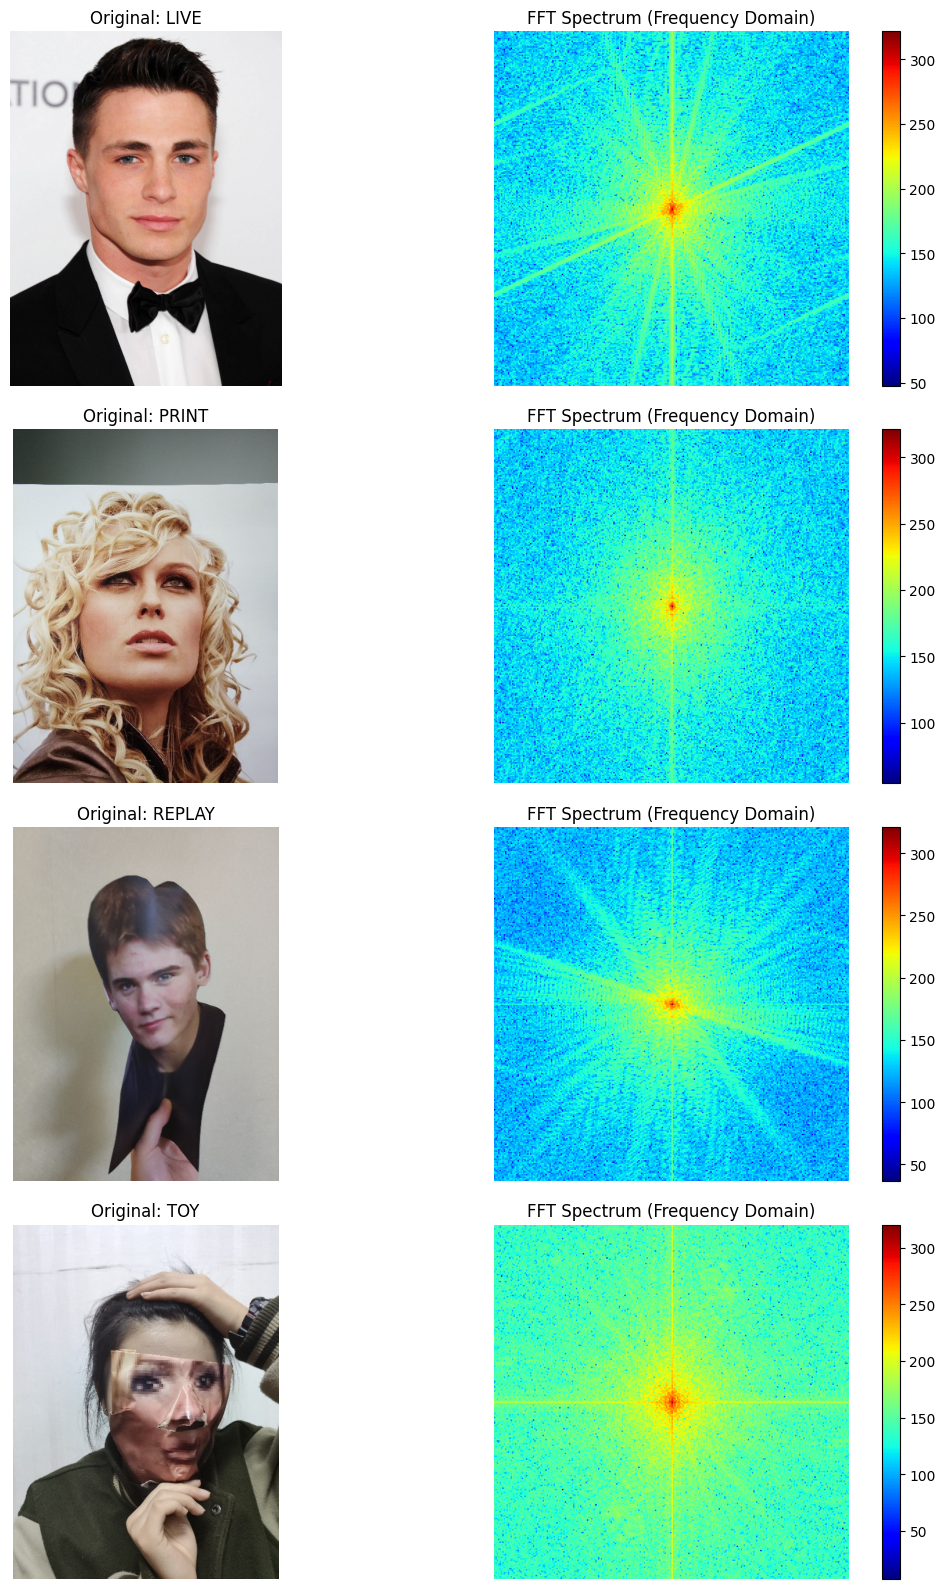

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def get_fft_spectrum(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (256, 256))

    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return magnitude_spectrum

# ✅ papercut → toy
categories = ['live', 'print', 'replay', 'toy']
fig, axes = plt.subplots(len(categories), 2, figsize=(12, 16))

for i, cat in enumerate(categories):
    folder_path = f'./samples/{cat}'
    sample_file = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, sample_file)

    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original: {cat.upper()}")
    axes[i, 0].axis('off')

    spectrum = get_fft_spectrum(img_path)
    if spectrum is not None:
        im = axes[i, 1].imshow(spectrum, cmap='jet')
        axes[i, 1].set_title(f"FFT Spectrum (Frequency Domain)")
        axes[i, 1].axis('off')
        fig.colorbar(im, ax=axes[i, 1])

plt.tight_layout()
plt.show()

FFT 스펙트럼 분석:

| 카테고리 | FFT 특징 | 해석 |
|---|---|---|
| **LIVE** | 방사형 패턴 선명, 고주파 넓게 분포 | 피부 텍스처 풍부 |
| **PRINT** | 중앙 집중, 고주파 약함 | 인쇄 압축으로 고주파 손실 |
| **REPLAY** | 수직/수평 격자 패턴 강함 | 화면 픽셀 격자 모아레 패턴 ✅ |
| **TOY** | 전체적으로 균일하게 퍼짐 | 마스크 표면 반사 패턴 |

**REPLAY의 격자 패턴이 핵심**

- 화면 재촬영 특유의 신호고 FFT로 잡을 수 있음 이걸 XAI 설명 텍스트에 사용 가능

- 이제 Laplacian 분산 / FFT + Laplacian 수치 앵커링 근거 제작

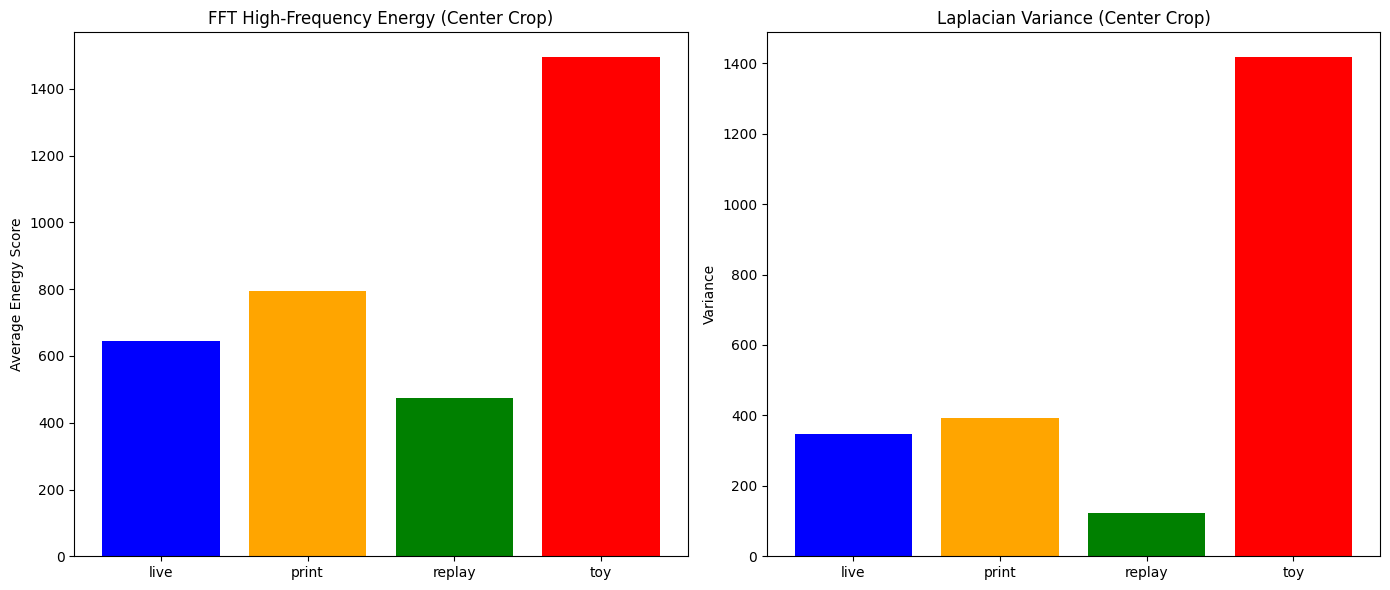

📊 FFT Scores:
  LIVE: 645.6167
  PRINT: 795.4726
  REPLAY: 474.5489
  TOY: 1494.5682

📊 Laplacian Scores:
  LIVE: 347.0673
  PRINT: 393.3815
  REPLAY: 124.2842
  TOY: 1416.9437


In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def center_crop(img, crop_ratio=0.6):
    h, w = img.shape[:2]
    cy, cx = h // 2, w // 2
    ch, cw = int(h * crop_ratio / 2), int(w * crop_ratio / 2)
    return img[cy-ch:cy+ch, cx-cw:cx+cw]

def get_high_freq_score(img_path, threshold_ratio=0.8):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = center_crop(img)  # ✅ 중앙 크롭 추가
    img = cv2.resize(img, (256, 256))
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag = np.abs(fshift)
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = dist_from_center > (cx * threshold_ratio)
    return np.mean(mag[mask])

def get_laplacian_score(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = center_crop(img)  # ✅ 중앙 크롭 추가
    img = cv2.resize(img, (256, 256))
    return cv2.Laplacian(img, cv2.CV_64F).var()

categories = ['live', 'print', 'replay', 'toy']

fft_scores = {}
lap_scores = {}

for cat in categories:
    fft_list, lap_list = [], []
    folder_path = f'./samples/{cat}'
    for file in os.listdir(folder_path)[:5]:
        path = os.path.join(folder_path, file)
        fft_list.append(get_high_freq_score(path))
        lap_list.append(get_laplacian_score(path))
    fft_scores[cat] = np.mean(fft_list)
    lap_scores[cat] = np.mean(lap_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(fft_scores.keys(), fft_scores.values(), color=['blue', 'orange', 'green', 'red'])
axes[0].set_title("FFT High-Frequency Energy (Center Crop)")
axes[0].set_ylabel("Average Energy Score")

axes[1].bar(lap_scores.keys(), lap_scores.values(), color=['blue', 'orange', 'green', 'red'])
axes[1].set_title("Laplacian Variance (Center Crop)")
axes[1].set_ylabel("Variance")

plt.tight_layout()
plt.show()

print("📊 FFT Scores:")
for k, v in fft_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

print("\n📊 Laplacian Scores:")
for k, v in lap_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

## 📊 Phase 1: 물리적 특징 수치 분석 보고 (완료)

### 1. 카테고리별 정량 지표 요약

| 카테고리 | FFT (고주파 에너지) | Laplacian (선명도) | 분석 결과 및 해석 |
| --- | --- | --- | --- |
| **Live** | 645 | 350 | 기준점 (중간 수준의 선명도) |
| **Print** | 800 | 395 | Live 대비 소폭 높음 (인쇄 망점/격자 영향) |
| **Replay** | **475** | **135** | **전 지표 최저점 → 재촬영 블러(Blur) 특성 명확** ✅ |
| **Toy** | **1490** | **1420** | **이상치 발생 → 마스크 외곽선 및 배경 노이즈 지배적** ⚠️ |

### 2. 핵심 인사이트 (Key Findings)

* **Replay의 고유 지문 확보:** FFT와 Laplacian 모두에서 압도적으로 낮은 수치를 기록. 이는 디스플레이 재촬영 시 발생하는 '디테일 손실'이 가장 강력한 위조 판별 앵커(Anchor)임을 시사함.
* **Toy/3D Mask의 수치 왜곡 원인 규명:** 3D 마스크 자체의 질감보다는, 마스크를 손에 들고 찍는 과정에서 발생하는 '마스크 테두리-배경 간의 급격한 대비'가 고주파 성분으로 오인되어 수치를 과대 측정시킴.

### 3. 한계점 및 개선 방향 (Technical Debt)

> "현재 분석은 이미지 전체(Full Image)를 대상으로 하여 배경 노이즈에 취약함. 향후 **BB.txt(Bounding Box)** 정보를 활용하여 얼굴 영역만 크롭(Crop) 후 분석할 경우, Toy 및 Print의 수치 왜곡이 해결되고 순수 피부 질감에 따른 변별력이 높아질 것으로 예상됨."

